In [3]:
from hplib import hplib as hpl
# import hplib_database as db
import pandas as pd


# Calling ambient temperatures

In [4]:
# ambient temperature for the location

import requests


def get_ambient_temperature(
    latitude: float,
    longitude: float,
    year: int
) -> pd.Series:
    """
    Get hourly ambient air temperature for a given location and year.

    Parameters
    ----------
    latitude : float
        Latitude in WGS84.
    longitude : float
        Longitude in WGS84.
    year : int
        Year for which the temperature data is requested.

    Returns
    -------
    pd.Series
        Hourly ambient temperature in °C, indexed by local time.

    Notes
    -----
    Uses Open-Meteo's Historical Weather API with ERA5-Land.
    ERA5-Land provides hourly data at approximately 11 km resolution.
    """

    start_date = f"{year}-01-01"
    end_date = f"{year}-12-31"

    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": "temperature_2m",
        "temperature_unit": "celsius",
        "timezone": "Europe/Berlin",
        "models": "era5_land",
    }

    response = requests.get(url, params=params)
    response.raise_for_status()

    data = response.json()

    temperature = pd.Series(
        data["hourly"]["temperature_2m"],
        index=pd.to_datetime(data["hourly"]["time"]),
        name="ambient_temperature",
    )

    return temperature


In [5]:
T_amb = get_ambient_temperature(latitude=52.5200, longitude=13.4050, year=2022)

# Loading hplib

In [6]:
hp_db = hpl.load_database()
hp_db

,Manufacturer,Model,Date,Type,Subtype,Group,Refrigerant,Mass of Refrigerant [kg],SPL indoor [dBA],SPL outdoor [dBA],...,p2_P_el_c [1/°C],p3_P_el_c [-],p4_P_el_c [1/°C],p1_EER [-],p2_EER [-],p3_EER [-],p4_EER [-],MAPE_P_el_cooling,MAPE_EER,MAPE_Pdc
0,Advantix,i-SHWAK V4 06,2020-05-26,Outdoor Air/Water,Regulated,1.0,R410a,2.68,35.0,64.0,...,-0.010769,-0.763316,-70.588606,37.392760,0.046170,6.295339,-37.488343,12.221419,6.840097,9.194424
1,Advantix,i-SHWAK V4 08,2020-05-26,Outdoor Air/Water,Regulated,1.0,R410a,2.20,35.0,64.0,...,-0.010295,-1.008835,-70.584924,53.317794,0.045359,6.373991,-53.417576,8.557697,5.543797,6.180972
2,Advantix,i-SHWAK V4 10,2020-05-26,Outdoor Air/Water,Regulated,1.0,R410a,3.45,39.0,64.0,...,-0.009974,-1.070117,-71.138737,-38.300289,0.055509,10.401023,38.090395,12.129224,4.233019,12.245197
3,Advantix,i-SHWAK V4 12,2020-05-26,Outdoor Air/Water,Regulated,1.0,R410a,3.45,39.0,65.0,...,-0.009670,-1.199828,-78.344134,-106.042312,0.055461,10.417087,105.831755,10.736661,4.251784,11.085391
4,Advantix,i-SHWAK V4 14T,2020-05-26,Outdoor Air/Water,Regulated,1.0,R410a,4.40,40.0,68.0,...,-0.009060,-1.464498,-70.578508,-106.042312,0.055461,10.417087,105.831755,6.954977,4.251784,7.852487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
506,Generic,Generic,NaN,Brine/Water,Regulated,2.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
507,Generic,Generic,NaN,Water/Water,Regulated,3.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
508,Generic,Generic,NaN,Outdoor Air/Water,On-Off,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
509,Generic,Generic,NaN,Brine/Water,On-Off,5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
hp_models = hp_db.groupby(['Type', 'Refrigerant']).agg({'Model': lambda x: ', '.join(x)})
hp_models

Model
Type              Refrigerant                                                   
Brine/Water       Other        WPC 04 cool, average climates, WPE-I 04 H(K)(W...
                  R134a                                                WPF 27 HT
                  R290                                      ecoGEO B1/C1 1-6 PRO
                  R32          EGSAX06D9W(G) (3PH), EGSAX10D9W(G) (3PH), Aqua...
                  R407c        CTC EcoAir 435 1x230V, CTC EcoPart 406 1x230V,...
                  R410a        Bosch Compress 6000 10 LW, Bosch Compress 6000...
Outdoor Air/Water Other        HPA-O 10 C Premium, HPA-O 13 C Premium, HPA-O ...
                  R1234yf                      RAS-4WHNPE RWD-4.0NWE-200S - with
                  R290         ECOAIR 1-7 PRO, ECOAIR 3-12 PRO, HA 10-6 O, HA...
                  R32          AW-YHPS04-H91 + AW-WHPS0406-N91, AW-YHPS04-H91...
                  R407c        AEROTOP T20, AEROTOP T26, AEROTOP T32, AEROTOP...
                  R410a        i-SHWAK V4 06, i-SHWAK V4 08, i-SHWAK V4 10, i...
Water/Water       R407c        WWC 100H/X, WWC 130H/X, WWC 160H/X, WWC 190H/X...
                  R410a        ATLANTIC GEOLIA 10, ATLANTIC GEOLIA 13, ATLANT...

In [8]:
hp_models.loc[('Outdoor Air/Water', 'R407c'),:]

Model    AEROTOP T20, AEROTOP T26, AEROTOP T32, AEROTOP...
Name: (Outdoor Air/Water, R407c), dtype: str

In [9]:
#The different groups of typs+subtype, the mean is just a workaround to get the group number, since it is the same for all rows in the group
hp_db.groupby(['Type', 'Subtype']).agg({'Group': 'mean'})

Group
Type              Subtype         
Brine/Water       On-Off       5.0
                  Regulated    2.0
Outdoor Air/Water On-Off       4.0
                  Regulated    1.0
Water/Water       On-Off       6.0
                  Regulated    3.0

# Air/water heatpump

In [10]:
#choosing a air/water heat pump model from database
model_name = 'AEROTOP T20'
# hp_db.loc[hp_db['Model'] == model_name, ['Manufacturer', 'Type', 'Refrigerant', 'COP_ref']]
parameters = hpl.get_parameters(model_name)

hp_air = hpl.HeatPump(parameters)


In [11]:
#or, choosing a generic one
'''
Finds a model in the database with the closes parameters, also matches the power.
But, it might be more useful to assume the COP is independent of the power.
Or, this probably just scales the electrical power according to the thermal power
'''
generic = hpl.get_parameters(model='Generic', group_id=1, t_in=-7, t_out=30, p_th=10000)
# hpl.HeatPump(generic_bottom)
generic

,Manufacturer,Model,MAPE_COP,MAPE_P_el,MAPE_P_th,P_th_h_ref [W],P_el_h_ref [W],COP_ref,Group,p1_P_th [1/°C],...,p4_Pdc [1/°C],p1_P_el_c [1/°C],p2_P_el_c [1/°C],p3_P_el_c [-],p4_P_el_c [1/°C],p1_EER [-],p2_EER [-],p3_EER [-],p4_EER [-],EER_ref
0,Generic,Generic,NaN,NaN,NaN,5770.985521,4082.414533,1.413621,1.0,64.083191,...,-71.453504,69.600608,-0.009208,-1.368638,-69.532741,-13.20985,0.06484,11.520049,12.9614,3.278167


In [12]:
import numpy as np

T_sink_in = np.array([90] * len(T_amb))  # constant sink temperature of 60°C
results = hp_air.simulate(t_in_primary = T_amb.values, t_in_secondary = T_sink_in, t_amb = T_amb.values, mode = 1)
results = pd.DataFrame(results)
results

,T_in,T_out,T_amb,COP,EER,P_el,P_th,m_dot
0,11.2,95,11.2,1.000000,0,12810.000000,12810.000000,0.610000
1,11.2,95,11.2,1.000000,0,12810.000000,12810.000000,0.610000
2,11.2,95,11.2,1.000000,0,12810.000000,12810.000000,0.610000
3,11.1,95,11.1,1.000000,0,12810.000000,12810.000000,0.610000
4,11.1,95,11.1,1.000000,0,12810.000000,12810.000000,0.610000
...,...,...,...,...,...,...,...,...
8755,15.1,95,15.1,1.175195,0,9834.362758,11557.294059,0.550347
8756,14.8,95,14.8,1.152211,0,9824.886275,11320.340713,0.539064
8757,14.9,95,14.9,1.159872,0,9828.045102,11399.276760,0.542823
8758,14.6,95,14.6,1.136888,0,9818.568619,11162.613826,0.531553


# Heating curve

In [ ]:
def heating_curve(T_amb, building_type):
    # Implementation for heating curve calculation
    # makes sense to implement for Low temperature buses, which essentially meets the space heating demand.
    # Heat pumps supplying high temps can be considered to not follow a heating curve, and output a constant temperature.
    

In [13]:
def calc_cop_carnot(T_sink_k, T_source_k):
    """
    Calculate the Carnot Coefficient of Performance (COP) for a heat pump.
    ----
    T_sink_k : pd.series or np.array
        Sink temperature in Kelvin.
    T_source_k : pd.series or np.array
        Source temperature in Kelvin.
    """
    return T_sink_k / (T_sink_k - T_source_k)


In [ ]:
def calc_COP(T_source, hp_model, hp_limits=None,T_sink = None):
    #TODO: fix a maximum COP

    """
    Calcultes the COP of a heat pump based on its carnot efficiency and provided limts.
    - Determines sink temperaturs based on a generic heating curve for low temperature heat pumps
    - Calculates COP based on carnot efficiency

    --------
    Parameters
    ----------
    T_source : array-like or scalar
        Source temperature(s) in Celsius.
    T_sink : array-like or scalar, optional
        Required for high temperature heat pumps.\
    hp_model : str
        Heat pump model type,
        a/w_lt : low temperature air/water heat pump, uses a heating curve to determine T_sink
        a/w_ht:  high temperature air/water heat pump
    """
    perf_df = pd.DataFrame({}) #adding to a df, to make debugging or proof-checking easier
    if hp_limits is None: 
        hp_limits = {
            'COP' : 3.0,
            'Op_point' : [5,35], #source,sink
            'low_limit' : -5,
            'high_limit' : 65
        }
        print("No hp_limits provided, using defaults\n", hp_limits)

    T_source = np.array(T_source)  # Ensure T_source is a numpy array for interpolation

    #T_sink determined with heating curve for low temp HPs
    if hp_model.lower() == 'a/w_lt': #TODO: change this to for all low temperature heat pumps, not just air/water
        heating_curve = {'T_amb': [-10, 15], 'T_supply':[45,20]} #example heating curve for low temperature air/water heat pump        
        T_sink = np.interp(T_source, heating_curve['T_amb'], heating_curve['T_supply'])

    else:
        #converting single scalar T_sink value to array of same length as T_source, only if T_source is also a series
        if type(T_sink) is int or type(T_sink) is float:
            if type(T_source) is not int or type(T_source) is not float:
                T_sink = np.array([T_sink] * len(T_source)) 
        if len(T_sink) != len(T_source):
            raise ValueError("T_sink must be the same length as T_source.")
        if T_sink is None:
            raise ValueError("T_sink must be provided for non-low temperature heat pumps.")

    #converting temperatures to Kelvin for cop calculation
    T_sink_k = T_sink + 273.15
    T_source_k = T_source + 273.15

    #Determining cop using carnot efficiency
    eta_2 = hp_limits['COP']/calc_cop_carnot(hp_limits['Op_point'][1] + 273.15, hp_limits['Op_point'][0] + 273.15)
    print(f"eta_2: {eta_2}")

    cop = eta_2 * calc_cop_carnot(T_sink_k, T_source_k)

    low_limit = hp_limits.get('low_limit', None)
    high_limit = hp_limits.get('high_limit', None)
    if low_limit is not None:
        low_limit = low_limit + 273.15  # Convert low limit to Kelvin
        breach_inxs = T_source_k < low_limit
        cop = np.where(breach_inxs, 0, cop)
    if high_limit is not None:
        high_limit = high_limit + 273.15  # Convert high limit to Kelvin
        breach_inxs = T_source_k > high_limit
        cop = np.where(breach_inxs, 0, cop)

    inf_inxs = T_source_k == T_sink_k
    cop = np.where(inf_inxs, 0, cop)

    T_lift = T_sink_k - T_source_k
    T_lift_min = 10 #minimum 10k difference between source and sink, for mathematical feasibility, and to avoid unrealistic high COPs
    cop = np.where(T_lift <= 10, 0, cop)
    
    perf_df['T_source'] = T_source
    perf_df['T_sink'] = T_sink
    perf_df['carnot'] = calc_cop_carnot(T_sink_k, T_source_k)
    perf_df['cop'] = cop
    return perf_df


In [31]:
res = calc_COP(T_source=T_amb.values, hp_model='a/w_lt', hp_limits=None)
res

No hp_limits provided, using defaults
 {'COP': 3.0, 'Op_point': [5, 35], 'low_limit': -5, 'high_limit': 65}
eta_2: 0.2920655524906701


C:\Users\rizal\AppData\Local\Temp\ipykernel_7872\3150240756.py:10: RuntimeWarning: divide by zero encountered in divide
  return T_sink_k / (T_sink_k - T_source_k)


,T_source,T_sink,carnot,cop
0,11.2,23.8,23.567460,6.883243
1,11.2,23.8,23.567460,6.883243
2,11.2,23.8,23.567460,6.883243
3,11.1,23.9,23.207031,6.777974
4,11.1,23.9,23.207031,6.777974
...,...,...,...,...
8755,15.1,20.0,59.826531,0.000000
8756,14.8,20.2,54.324074,0.000000
8757,14.9,20.1,56.394231,0.000000
8758,14.6,20.4,50.612069,0.000000


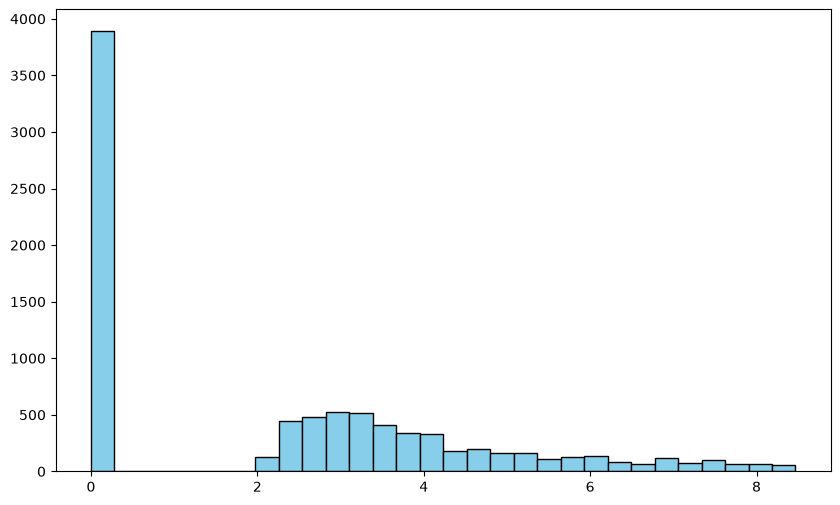

In [33]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(res['cop'], bins=30, color='skyblue', edgecolor='black')

plt.show()